<h2 align="center" style="font-size: 18px;">Задание №2</h2>
<h2 align="center" style="font-size: 18px;">тема: «Отбор признаков в машинном обучении»</h2>

## Описание задачи


## Задание

При выполнении задания «Классификация» была получена матрица признаков Харалика "Krylova_all.csv" (объединённые файлы "YES.csv" и "NO.csv").

Для извлечения наиболее значимых признаков использовать алгоритмы:
- **Lasso** (L1-регуляризация)
- **Relieff** (метод-фильтр на основе ближайших соседей)
- **fsnca** (Neighborhood Component Analysis)

Сформировать новые матрицы признаков и выбрать наилучшую смесь

## Процесс выполнения

#### Lasso (L1-регуляризация)
Данный алгоритм существует под названием `LassoCV` в библиотеке scikit-learn. Признаки с ненулевыми коэффициентами считаются отобранными.

#### Relieff
Прямого аналога в Python нет, можно реализовать самостоятельно по формулам из лекций. Признаки отбираются по порогу весов (выше медианы).

#### fscnca (Neighborhood Component Analysis)
Прямого аналога в Python нет, можно реализовать самостоятельно по формулам из лекций. Алгоритм оптимизирует веса признаков, максимизируя вероятность правильной классификации методом ближайших соседей. Отбираются признаки с весом > 0.2.

#### Формирование наилучшей смеси
Индексы признаков, отобранных каждым методом, объединяются, дубликаты удаляются. На основе полученных индексов из исходного файла создается новая матрица признаков и сохраняется в "Krylova_all_NEW.csv".

### Загрузка данных, формирование матрицы

In [1]:
import pandas as pd
import numpy as np

# Загрузка данных с указанием, что первая строка - это заголовки
yes_df = pd.read_csv('/home/katya/Магистратура КФУ/3 семестр/Машинное обучение в медицине/Репозиторий для гитхаба/Machine-learning-in-medicine-tasks/task_1/YES.csv', header=0)
no_df = pd.read_csv('/home/katya/Магистратура КФУ/3 семестр/Машинное обучение в медицине/Репозиторий для гитхаба/Machine-learning-in-medicine-tasks/task_1/NO.csv', header=0)

# Добавление меток классов
yes_df['label'] = 1  # YES - пневмония
no_df['label'] = 0   # NO - норма

# Объединение датасетов
df = pd.concat([yes_df, no_df], ignore_index=True)

# Перемешивание данных
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Размер итогового датасета: {df.shape}")

Размер итогового датасета: (624, 113)


In [2]:
df.head()

,contrast_G_16_d_2_0,dissimilarity_G_16_d_2_0,homogeneity_G_16_d_2_0,energy_G_16_d_2_0,correlation_G_16_d_2_0,ASM_G_16_d_2_0,maximum_probability_G_16_d_2_0,entropy_G_16_d_2_0,variance_G_16_d_2_0,sum_average_G_16_d_2_0,...,ASM_G_128_d_4_135,maximum_probability_G_128_d_4_135,entropy_G_128_d_4_135,variance_G_128_d_4_135,sum_average_G_128_d_4_135,sum_variance_G_128_d_4_135,sum_entropy_G_128_d_4_135,difference_variance_G_128_d_4_135,difference_entropy_G_128_d_4_135,label
0,0.359806,0.302811,0.851329,0.241786,0.975252,0.058460,0.102388,4.499353,7.269348,16.679568,...,0.001036,0.007601,10.327327,521.713041,148.275564,2066.008683,7.350658,11.496626,3.122002,0
1,0.255826,0.239291,0.881631,0.233266,0.987644,0.054413,0.095877,4.633798,10.352420,14.269501,...,0.002064,0.035861,10.558304,755.694246,127.598413,3002.313850,7.563951,10.817842,3.220978,0
2,0.265655,0.219632,0.892117,0.239797,0.990018,0.057503,0.099310,4.548832,13.306717,13.925448,...,0.007941,0.084859,10.157395,988.897658,124.410697,3929.584855,7.378318,17.733411,3.139624,1
3,0.215687,0.177952,0.913177,0.262728,0.989365,0.069026,0.115246,4.282261,10.140781,12.950540,...,0.001926,0.016999,9.950201,726.618285,116.553164,2888.417355,7.448434,12.494762,2.867977,1
4,0.287238,0.235904,0.884567,0.262186,0.978934,0.068742,0.119925,4.308205,6.817468,16.894028,...,0.001279,0.003390,10.016360,486.774178,150.075473,1931.165683,7.348945,9.889667,2.837557,0


In [3]:
# Перемешивание данных
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Размер итогового датасета: {df.shape}")
print(f"Распределение классов:\n{df['label'].value_counts()}")

# Сохранение объединенного файла
df.to_csv('Krylova_all.csv', index=False, header=False)
print("Файл Krylova_all.csv сохранен")

Размер итогового датасета: (624, 113)
Распределение классов:
label
1    390
0    234
Name: count, dtype: int64
Файл Krylova_all.csv сохранен


In [4]:
df.head()

,contrast_G_16_d_2_0,dissimilarity_G_16_d_2_0,homogeneity_G_16_d_2_0,energy_G_16_d_2_0,correlation_G_16_d_2_0,ASM_G_16_d_2_0,maximum_probability_G_16_d_2_0,entropy_G_16_d_2_0,variance_G_16_d_2_0,sum_average_G_16_d_2_0,...,ASM_G_128_d_4_135,maximum_probability_G_128_d_4_135,entropy_G_128_d_4_135,variance_G_128_d_4_135,sum_average_G_128_d_4_135,sum_variance_G_128_d_4_135,sum_entropy_G_128_d_4_135,difference_variance_G_128_d_4_135,difference_entropy_G_128_d_4_135,label
0,0.290476,0.222222,0.892449,0.251417,0.991379,0.063210,0.174413,4.625694,16.847793,11.771404,...,0.021709,0.145587,10.008168,1263.154203,105.572907,5019.769841,7.259569,23.193064,3.258516,1
1,0.211207,0.171795,0.915887,0.256407,0.992679,0.065745,0.136553,4.393721,14.425691,13.272308,...,0.005949,0.069950,9.961193,1068.851847,118.744349,4256.470997,7.478234,13.433633,2.879944,0
2,0.381532,0.200555,0.906498,0.303515,0.981603,0.092121,0.156885,4.039695,10.369307,15.438965,...,0.006750,0.070973,9.490412,775.418669,137.392124,3062.185656,6.996627,32.665346,2.955080,0
3,0.287827,0.170203,0.922209,0.287744,0.985251,0.082797,0.163082,4.143323,9.757370,11.358346,...,0.003813,0.032001,9.686267,689.220866,103.533630,2720.655001,7.326679,30.283874,2.822038,1
4,0.290716,0.197431,0.907665,0.284027,0.983957,0.080671,0.180332,4.242419,9.060767,12.955278,...,0.002110,0.011550,9.991863,643.456345,116.642236,2539.545073,7.330347,26.999469,2.961424,1


### Lasso (L1-регуляризация)

> **Примечание:** Знак коэффициента Lasso указывает на направление связи:
> - **Положительный** → признак увеличивает вероятность класса 1 (пневмония)
> - **Отрицательный** → признак увеличивает вероятность класса 0 (норма)
> 
> Для оценки важности признака используется **модуль** коэффициента.
> Перед использованием LassoCV из библиотеки scikit-learn необходимо провести нормировку признаков, для этого можно испольщовать StandardScaler

In [5]:
# импорт нужных библиотек
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler


In [6]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values 

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Lasso с кросс-валидацией
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_scaled, y)

# Отбираем признаки с ненулевыми коэффициентами
lasso_features = np.where(lasso.coef_ != 0)[0]     # Индексы столбцов отобранных признаков
lasso_coefs = lasso.coef_[lasso_features]          # значение важности

/home/katya/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.437e-02, tolerance: 1.153e-02
  model = cd_fast.enet_coordinate_descent_gram(
/home/katya/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.052e-02, tolerance: 1.153e-02
  model = cd_fast.enet_coordinate_descent_gram(
/home/katya/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality

/home/katya/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.324e-02, tolerance: 1.162e-02
  model = cd_fast.enet_coordinate_descent_gram(
/home/katya/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.092e-02, tolerance: 1.162e-02
  model = cd_fast.enet_coordinate_descent_gram(
/home/katya/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality

/home/katya/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.766e-02, tolerance: 1.169e-02
  model = cd_fast.enet_coordinate_descent_gram(
/home/katya/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.739e-02, tolerance: 1.169e-02
  model = cd_fast.enet_coordinate_descent_gram(
/home/katya/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality

In [7]:
# Полученные коэффициенты
lasso_coefs

array([-6.06384043e-01,  9.56587720e-02,  4.19514539e-01,  2.22350515e-01,
        1.67806979e+00, -5.57326320e-02, -4.00042812e-01, -2.06102148e-01,
        1.49600765e-01, -2.87122889e-01, -4.28599153e-01,  1.57424680e-01,
       -3.25467116e-01,  2.23777482e-01, -4.00753723e-01, -1.70866966e-01,
        1.04714287e-01, -4.01739209e-01, -1.94609490e-03, -9.55712480e-01,
        5.58775460e-01, -1.38288873e-01, -3.01246137e-01, -2.31539222e-01,
       -2.84604803e-01,  1.14299243e+00, -1.86227081e-03,  8.83494893e-01,
        7.50532488e-02, -1.78073645e-01, -2.75894503e-01,  3.48004362e-01,
        5.41750761e-01,  5.51277048e-01,  3.19793794e-02,  6.58752792e-01,
       -1.62161265e-01, -2.73924827e-01, -2.43038114e-01, -1.77222862e-01,
        5.76192978e-01,  2.76417264e-02,  2.41520495e-01, -3.38335490e-03,
       -4.69966483e-03, -5.18122879e-04,  5.24301929e-03, -6.58919306e-01,
       -7.74840780e-01, -7.84993401e-01])

In [8]:
# Индексы столбцов отобранных признаков
lasso_features

array([  1,   2,   4,   6,   7,   8,  11,  12,  13,  14,  15,  20,  25,
        28,  29,  32,  33,  34,  37,  39,  41,  43,  45,  46,  53,  54,
        57,  58,  60,  61,  62,  63,  67,  68,  69,  71,  72,  82,  83,
        86,  87,  88,  89,  93,  96,  97,  99, 100, 105, 110])

### ReliefF



Метод-фильтр, оценивающий важность признаков на основе анализа ближайших соседей.

**Основная идея:** Признак тем важнее, чем:
- ближе он у объектов **одного класса**
- дальше у объектов **разных классов**


In [10]:


def relieff_manual(X, y, n_neighbors=5, n_iterations=None):
    """
    Ручная реализация ReliefF
    
    Parameters:
    X: матрица признаков (n_samples, n_features)
    y: вектор классов (0 или 1)
    n_neighbors: количество соседей K
    n_iterations: количество итераций (по умолчанию = все объекты)
    """
    n_samples, n_features = X.shape
    n_iterations = n_iterations or n_samples
    
    # Инициализация весов
    weights = np.zeros(n_features)
    
    # Нормализация признаков (для расстояний)
    X_norm = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0) + 1e-10)
    
    # Для каждого класса находим свои априорные вероятности
    classes = np.unique(y)
    p_classes = {c: np.mean(y == c) for c in classes}
    
    for _ in range(n_iterations):
        # Случайный объект
        idx = np.random.randint(n_samples)
        x_r = X_norm[idx]
        y_r = y[idx]
        
        # Поиск соседей
        # Разделяем на тот же класс и другие классы
        same_class_idx = np.where(y == y_r)[0]
        diff_class_idx = np.where(y != y_r)[0]
        
        # Удаляем сам объект
        same_class_idx = same_class_idx[same_class_idx != idx]
        
        # Выбираем случайных соседей (упрощение)
        if len(same_class_idx) >= n_neighbors:
            same_neighbors = np.random.choice(same_class_idx, n_neighbors, replace=False)
        else:
            same_neighbors = same_class_idx
            
        if len(diff_class_idx) >= n_neighbors:
            diff_neighbors = np.random.choice(diff_class_idx, n_neighbors, replace=False)
        else:
            diff_neighbors = diff_class_idx
        
        # Обновление весов для каждого признака
        for j in range(n_features):
            # По соседям из того же класса (уменьшаем вес)
            for neighbor_idx in same_neighbors:
                diff = np.abs(x_r[j] - X_norm[neighbor_idx, j])
                weights[j] -= diff / (n_iterations * n_neighbors)
            
            # По соседям из другого класса (увеличиваем вес)
            for neighbor_idx in diff_neighbors:
                diff = np.abs(x_r[j] - X_norm[neighbor_idx, j])
                # Упрощенная формула (без вероятностей)
                weights[j] += diff / (n_iterations * n_neighbors)
    
    return weights

# Использование
weights = relieff_manual(X_scaled, y, n_neighbors=5)
relieff_features = np.where(weights > np.median(weights))[0]

print(f"ReliefF отобрал {len(relieff_features)} признаков")
print(f"Индексы: {relieff_features}")

ReliefF отобрал 56 признаков
Индексы: [  3   4   5   6   8  10  11  17  19  20  22  24  25  29  30  31  32  33
  34  35  36  38  39  40  41  45  47  48  50  52  53  58  60  64  66  68
  70  72  74  76  78  80  82  84  86  88  91  92  94  96 100 102 104 106
 108 110]


### fsnca (Neighborhood Component Analysis)

In [14]:
from scipy.optimize import minimize

def fscnca_manual(X, y, lambda_reg=0.001, max_iter=2):
    """
    Оптимизированная реализация fscnca
    Параметры:
        max_iter=30 - оптимально для скорости/качества
        lambda_reg=0.001 - регуляризация
    """
    n_samples, n_features = X.shape
    
    # Нормализация данных
    X_norm = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-10)
    
    # Целевая функция (отрицательная, т.к. минимизируем)
    def objective(w):
        w = np.abs(w)  # веса неотрицательные
        w_sq = w**2
        
        total_prob = 0
        
        for i in range(n_samples):
            # Расстояния от i до всех остальных
            distances = np.sum(w_sq * np.abs(X_norm[i] - X_norm)**2, axis=1)
            distances[i] = np.inf  # исключаем сам объект
            
            # Вероятности выбора соседей
            exp_dist = np.exp(-distances)
            p = exp_dist / (exp_dist.sum() + 1e-10)
            
            # Вероятность правильной классификации
            same_class = (y == y[i])
            total_prob += np.sum(p[same_class])
        
        # Целевая функция с регуляризацией
        return -(total_prob / n_samples - lambda_reg * np.sum(w_sq))
    
    # Начальное приближение
    w0 = np.ones(n_features) * 0.5
    
    # Оптимизация с уменьшенным числом итераций
    result = minimize(objective, w0, method='L-BFGS-B', 
                     options={'maxiter': max_iter, 'disp': False})
    
    weights = np.abs(result.x)
    return weights

# Использование
print("Запуск fscnca (30 итераций)...")
weights = fscnca_manual(X_scaled, y, lambda_reg=0.001, max_iter=30)

# Отбор признаков с весом > 0.2
fscnca_features = np.where(weights > 0.2)[0]

print(f"fscnca отобрал {len(fscnca_features)} признаков из {X_scaled.shape[1]}")
print(f"Индексы: {fscnca_features}")
print(f"Веса: {weights[fscnca_features]}")

Запуск fscnca (30 итераций)...
fscnca отобрал 29 признаков из 112
Индексы: [  9  22  23  24  26  28  30  34  36  37  38  39  40  50  51  52  62  68
  72  76  79  87  89  90  93 100 104 107 111]
Веса: [0.50703593 0.21848319 0.6225735  0.22156302 3.06078919 0.2476052
 1.8091822  0.91854122 0.2954728  0.74496155 0.30071678 1.27457438
 2.00138093 0.2184765  0.62260066 0.22737095 0.38005483 1.14894855
 1.97175849 0.59160501 0.30723568 0.52688547 0.45318816 1.48093266
 0.45863692 0.72340671 0.52672895 0.30805984 1.3244612 ]


### Обучение моделей на данных из отобранных признаков

Формирование датафреймов из разных наборов признаков

In [55]:
# 1. Lasso - датафрейм только с отобранными признаками (без target)
X_lasso = df.iloc[:, lasso_features].copy()  # датафрейм

# 2. ReliefF
X_relieff = df.iloc[:, relieff_features].copy()

# 3. fscnca
X_fscnca = df.iloc[:, fscnca_features].copy()

# Попарные объединения (уникальные индексы)
lasso_relieff = np.unique(np.concatenate([lasso_features, relieff_features]))
lasso_fscnca = np.unique(np.concatenate([lasso_features, fscnca_features]))
relieff_fscnca = np.unique(np.concatenate([relieff_features, fscnca_features]))

# Все три метода вместе
all_three = np.unique(np.concatenate([lasso_features, relieff_features, fscnca_features]))

# Создаем датафреймы
X_lasso_relieff = df.iloc[:, lasso_relieff].copy()
X_lasso_fscnca = df.iloc[:, lasso_fscnca].copy()
X_relieff_fscnca = df.iloc[:, relieff_fscnca].copy()
X_all_three = df.iloc[:, all_three].copy()

y = df['label'].copy()                        # target

Обучение на 3-х наборах признаков аналогично заданию 1

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier, 
    AdaBoostClassifier,
    BaggingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

In [57]:
# 25 классификаторов

classifiers = {
    # Линейные модели
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    
    # SVM с разными ядрами
    "Linear SVM": SVC(kernel='linear', probability=True, random_state=42),
    "SVM RBF": SVC(kernel='rbf', probability=True, random_state=42),
    "SVM Polynomial": SVC(kernel='poly', probability=True, random_state=42),
    "SVM Sigmoid": SVC(kernel='sigmoid', probability=True, random_state=42),
    
    # Деревья и ансамбли
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    
    # Бустинг
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "GentleBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1), 
        n_estimators=50, 
        random_state=42,
        learning_rate=0.1
    ),
    "LogitBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=50, 
        random_state=42,
        learning_rate=1.0
    ),
    "RUSBoost": RandomForestClassifier(
        n_estimators=100, 
        class_weight='balanced', 
        random_state=42
    ),
    
    # kNN с разными метриками
    "kNN Euclidean": KNeighborsClassifier(metric='euclidean'),
    "kNN Minkowski": KNeighborsClassifier(metric='minkowski'),
    "kNN Cityblock": KNeighborsClassifier(metric='manhattan'),
    "kNN Chebyshev": KNeighborsClassifier(metric='chebyshev'),
    "kNN Cosine": KNeighborsClassifier(metric='cosine'),
    
    # Наивный Байес
    "Naive Bayes Gaussian": GaussianNB(),
    "Naive Bayes Multinomial": MultinomialNB(),
    "Naive Bayes Bernoulli": BernoulliNB(),
    
    # Дискриминантный анализ
    "Linear Discriminant Analysis (LDA)": LinearDiscriminantAnalysis(),
    "Quadratic Discriminant Analysis (QDA)": QuadraticDiscriminantAnalysis(),
    
    # Subspace методы
    "Subspace KNN": BaggingClassifier(
        estimator=KNeighborsClassifier(), 
        n_estimators=10, 
        random_state=42
    ),
    "Subspace Discriminant": BaggingClassifier(
        estimator=LinearDiscriminantAnalysis(), 
        n_estimators=10, 
        random_state=42
    ),
}

In [58]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [59]:
K_values = [3, 4, 5]

In [60]:
# Отдельная функция для специфичности
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2,2):
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp)

In [61]:
# Стандартизация для всех комбинаций
scaler = StandardScaler()

# Отдельные методы
X_lasso_scaled = scaler.fit_transform(X_lasso)
X_relieff_scaled = scaler.fit_transform(X_relieff)
X_fscnca_scaled = scaler.fit_transform(X_fscnca)

# Попарные комбинации
X_lasso_relieff_scaled = scaler.fit_transform(X_lasso_relieff)
X_lasso_fscnca_scaled = scaler.fit_transform(X_lasso_fscnca)
X_relieff_fscnca_scaled = scaler.fit_transform(X_relieff_fscnca)

# Все три вместе
X_all_three_scaled = scaler.fit_transform(X_all_three)

print("Масштабирование завершено для всех наборов:")
print(f"Lasso: {X_lasso_scaled.shape}")
print(f"ReliefF: {X_relieff_scaled.shape}")
print(f"fscnca: {X_fscnca_scaled.shape}")
print(f"Lasso+ReliefF: {X_lasso_relieff_scaled.shape}")
print(f"Lasso+fscnca: {X_lasso_fscnca_scaled.shape}")
print(f"ReliefF+fscnca: {X_relieff_fscnca_scaled.shape}")
print(f"All three: {X_all_three_scaled.shape}")

Масштабирование завершено для всех наборов:
Lasso: (624, 50)
ReliefF: (624, 56)
fscnca: (624, 29)
Lasso+ReliefF: (624, 82)
Lasso+fscnca: (624, 68)
ReliefF+fscnca: (624, 70)
All three: (624, 90)


In [62]:
def train_on_feature_set(X_data, y, set_name, classifiers, K_values=[3,4,5]):
    """
    Обучает все классификаторы на конкретном наборе признаков
    """
    print(f"\n{'='*60}")
    print(f"Обучение на наборе признаков, отобранных с помощью {set_name}...")
    print(f"{'='*60}")
    print(f"Размер данных: {X_data.shape}")
    
    # Масштабирование
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_data)
    
    results = []
    
    for name, model in classifiers.items():
        print(f"\nОбучаем модель: {name}...")
        acc_list, sens_list, spec_list = [], [], []
        
        try:
            for K in K_values:
                skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
                acc_fold, sens_fold, spec_fold = [], [], []
                
                for train_idx, test_idx in skf.split(X_scaled, y):
                    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
                    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
                    
                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_test)
                    
                    acc_fold.append(accuracy_score(y_test, y_pred))
                    sens_fold.append(recall_score(y_test, y_pred, average='macro'))
                    spec_fold.append(specificity_score(y_test, y_pred))
                
                acc_list.append(np.mean(acc_fold))
                sens_list.append(np.mean(sens_fold))
                spec_list.append(np.mean(spec_fold))
            
            avg_acc = np.mean(acc_list)
            avg_sens = np.mean(sens_list)
            avg_spec = np.mean(spec_list)
            
            results.append({
                'Model': name,
                'Feature_Set': set_name,
                'Accuracy': avg_acc,
                'Sensitivity': avg_sens,
                'Specificity': avg_spec
            })
            
            print(f"  Результаты: Accuracy={avg_acc:.4f}, Sensitivity={avg_sens:.4f}, Specificity={avg_spec:.4f}")
            
        except Exception as e:
            print(f"  Модель пропущена из-за ошибки: {e}")
    
    return pd.DataFrame(results)


In [63]:
# Запуск для каждого отдельного метода
results_lasso = train_on_feature_set(X_lasso, y, "Lasso", classifiers)
results_relieff = train_on_feature_set(X_relieff, y, "ReliefF", classifiers)
results_fscnca = train_on_feature_set(X_fscnca, y, "fscnca", classifiers)

# Запуск для попарных комбинаций
results_lasso_relieff = train_on_feature_set(X_lasso_relieff, y, "Lasso+ReliefF", classifiers)
results_lasso_fscnca = train_on_feature_set(X_lasso_fscnca, y, "Lasso+fscnca", classifiers)
results_relieff_fscnca = train_on_feature_set(X_relieff_fscnca, y, "ReliefF+fscnca", classifiers)

# Запуск для всех трёх методов вместе
results_all_three = train_on_feature_set(X_all_three, y, "All_three_methods", classifiers)

# Сохраняем результаты
results_lasso.to_csv('results_lasso.csv', index=False)
results_relieff.to_csv('results_relieff.csv', index=False)
results_fscnca.to_csv('results_fscnca.csv', index=False)
results_lasso_relieff.to_csv('results_lasso_relieff.csv', index=False)
results_lasso_fscnca.to_csv('results_lasso_fscnca.csv', index=False)
results_relieff_fscnca.to_csv('results_relieff_fscnca.csv', index=False)


Обучение на наборе признаков, отобранных с помощью Lasso...
Размер данных: (624, 50)

Обучаем модель: Logistic Regression...
  Результаты: Accuracy=0.8889, Sensitivity=0.8758, Specificity=0.8233

Обучаем модель: Linear SVM...
  Результаты: Accuracy=0.9033, Sensitivity=0.8950, Specificity=0.8617

Обучаем модель: SVM RBF...
  Результаты: Accuracy=0.8830, Sensitivity=0.8620, Specificity=0.7778

Обучаем модель: SVM Polynomial...
  Результаты: Accuracy=0.8152, Sensitivity=0.7638, Specificity=0.5584

Обучаем модель: SVM Sigmoid...
  Результаты: Accuracy=0.7019, Sensitivity=0.6793, Specificity=0.5884

Обучаем модель: Decision Tree...
  Результаты: Accuracy=0.8146, Sensitivity=0.8018, Specificity=0.7506

Обучаем модель: Random Forest...
  Результаты: Accuracy=0.8750, Sensitivity=0.8575, Specificity=0.7877

Обучаем модель: Gradient Boosting...
  Результаты: Accuracy=0.8723, Sensitivity=0.8557, Specificity=0.7891

Обучаем модель: AdaBoost...
  Результаты: Accuracy=0.8494, Sensitivity=0.8279, Sp

  Результаты: Accuracy=0.8627, Sensitivity=0.8477, Specificity=0.7877

Обучаем модель: Subspace Discriminant...
  Результаты: Accuracy=0.8675, Sensitivity=0.8518, Specificity=0.7891

Обучение на наборе признаков, отобранных с помощью Lasso+ReliefF...
Размер данных: (624, 82)

Обучаем модель: Logistic Regression...
  Результаты: Accuracy=0.8894, Sensitivity=0.8782, Specificity=0.8332

Обучаем модель: Linear SVM...
  Результаты: Accuracy=0.9049, Sensitivity=0.8971, Specificity=0.8660

Обучаем модель: SVM RBF...
  Результаты: Accuracy=0.8819, Sensitivity=0.8608, Specificity=0.7763

Обучаем модель: SVM Polynomial...
  Результаты: Accuracy=0.8253, Sensitivity=0.7776, Specificity=0.5869

Обучаем модель: SVM Sigmoid...
  Результаты: Accuracy=0.6939, Sensitivity=0.6671, Specificity=0.5598

Обучаем модель: Decision Tree...
  Результаты: Accuracy=0.8061, Sensitivity=0.7923, Specificity=0.7377

Обучаем модель: Random Forest...
  Результаты: Accuracy=0.8729, Sensitivity=0.8541, Specificity=0.7791


  Результаты: Accuracy=0.9065, Sensitivity=0.9024, Specificity=0.8860

Обучаем модель: Quadratic Discriminant Analysis (QDA)...
  Модель пропущена из-за ошибки: The covariance matrix of class 0 is not full rank. Increase the value of `reg_param` to reduce the collinearity.

Обучаем модель: Subspace KNN...
  Результаты: Accuracy=0.8568, Sensitivity=0.8407, Specificity=0.7763

Обучаем модель: Subspace Discriminant...
  Результаты: Accuracy=0.9070, Sensitivity=0.9040, Specificity=0.8917

Обучение на наборе признаков, отобранных с помощью All_three_methods...
Размер данных: (624, 90)

Обучаем модель: Logistic Regression...
  Результаты: Accuracy=0.8899, Sensitivity=0.8786, Specificity=0.8332

Обучаем модель: Linear SVM...
  Результаты: Accuracy=0.9060, Sensitivity=0.8983, Specificity=0.8674

Обучаем модель: SVM RBF...
  Результаты: Accuracy=0.8798, Sensitivity=0.8600, Specificity=0.7806

Обучаем модель: SVM Polynomial...
  Результаты: Accuracy=0.8232, Sensitivity=0.7751, Specificity=0.5826

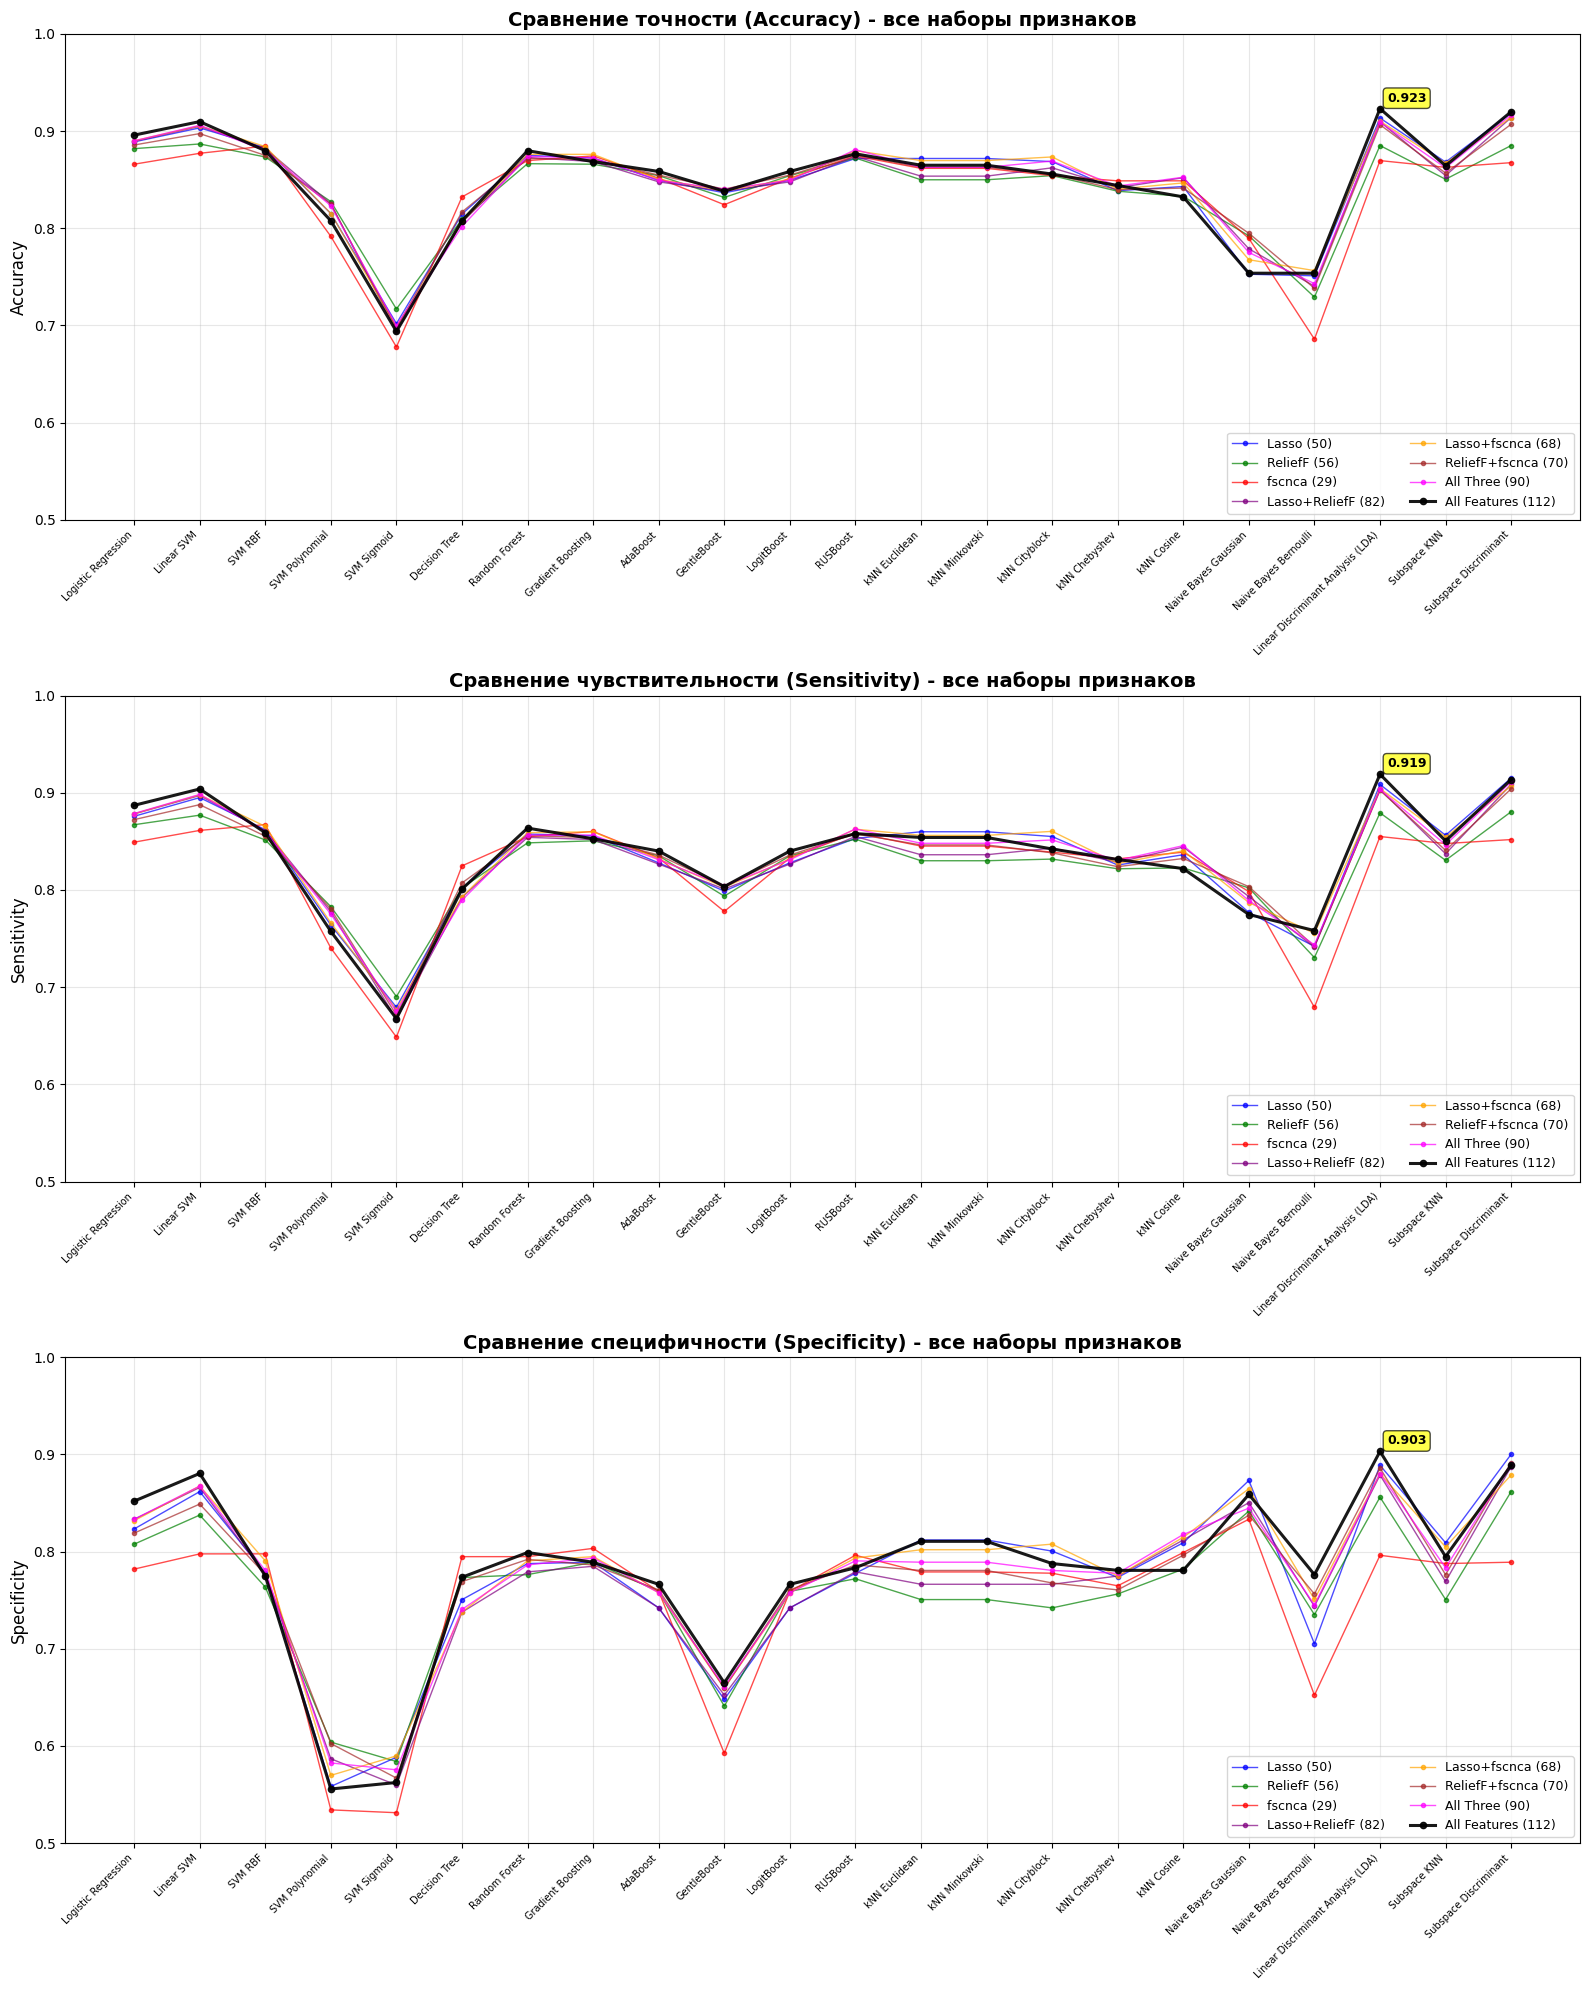

In [64]:
import matplotlib.pyplot as plt

# Загрузка базового результата (все признаки)
results_all = pd.read_csv('/home/katya/Магистратура КФУ/3 семестр/Машинное обучение в медицине/Репозиторий для гитхаба/Machine-learning-in-medicine-tasks/task_1/results.csv')

# Загрузка всех результатов отбора
results_lasso = pd.read_csv('results_lasso.csv')
results_relieff = pd.read_csv('results_relieff.csv')
results_fscnca = pd.read_csv('results_fscnca.csv')
results_lasso_relieff = pd.read_csv('results_lasso_relieff.csv')
results_lasso_fscnca = pd.read_csv('results_lasso_fscnca.csv')
results_relieff_fscnca = pd.read_csv('results_relieff_fscnca.csv')
results_all_three = pd.read_csv('results_all_three.csv')

# Добавляем идентификатор набора
results_all['Feature_Set'] = 'All Features (112)'
results_lasso['Feature_Set'] = 'Lasso (50)'
results_relieff['Feature_Set'] = 'ReliefF (56)'
results_fscnca['Feature_Set'] = 'fscnca (29)'
results_lasso_relieff['Feature_Set'] = 'Lasso+ReliefF (82)'
results_lasso_fscnca['Feature_Set'] = 'Lasso+fscnca (68)'
results_relieff_fscnca['Feature_Set'] = 'ReliefF+fscnca (70)'
results_all_three['Feature_Set'] = 'All Three (90)'

# Объединяем все результаты
all_results = pd.concat([
    results_all, 
    results_lasso, 
    results_relieff, 
    results_fscnca,
    results_lasso_relieff,
    results_lasso_fscnca,
    results_relieff_fscnca,
    results_all_three
], ignore_index=True)

# Получаем список всех моделей
models = all_results['Model'].unique()

# Цвета для графиков
colors = {
    'All Features (112)': 'black',  # Базовый - черный
    'Lasso (50)': 'blue',
    'ReliefF (56)': 'green',
    'fscnca (29)': 'red',
    'Lasso+ReliefF (82)': 'purple',
    'Lasso+fscnca (68)': 'orange',
    'ReliefF+fscnca (70)': 'brown',
    'All Three (90)': 'magenta'
}

# Создаем три графика
fig, axes = plt.subplots(3, 1, figsize=(16, 20))

# Метрики для отображения
metrics = ['Accuracy', 'Sensitivity', 'Specificity']
titles = ['Сравнение точности (Accuracy) - все наборы признаков', 
          'Сравнение чувствительности (Sensitivity) - все наборы признаков', 
          'Сравнение специфичности (Specificity) - все наборы признаков']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx]
    
    # Сначала строим все наборы отбора (тонкие линии)
    for feature_set in all_results['Feature_Set'].unique():
        if feature_set == 'All Features (112)':
            continue  # Базовый набор построим позже
            
        values = []
        for model in models:
            val = all_results[(all_results['Model'] == model) & 
                              (all_results['Feature_Set'] == feature_set)][metric].values
            values.append(val[0] if len(val) > 0 else np.nan)
        
        ax.plot(range(len(models)), values, 
                marker='o', 
                label=feature_set, 
                color=colors[feature_set],
                linewidth=1, 
                markersize=3,
                alpha=0.7)
    
    # Затем строим базовый набор (умеренно жирная черная линия)
    base_values = []
    for model in models:
        val = all_results[(all_results['Model'] == model) & 
                          (all_results['Feature_Set'] == 'All Features (112)')][metric].values
        base_values.append(val[0] if len(val) > 0 else np.nan)
    
    ax.plot(range(len(models)), base_values, 
            marker='o', 
            label='All Features (112)', 
            color='black',
            linewidth=2.2, 
            markersize=4.5,
            alpha=0.9,
            zorder=10)
    
    # Настройка графика
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    ax.set_ylim(0.5, 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=9, ncol=2)
    
    # Настройка подписей моделей по оси X
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=7)
    
    best_idx = np.argmax(base_values)
    best_model = models[best_idx]
    best_value = base_values[best_idx]
    ax.annotate(f'{best_value:.3f}', 
               xy=(best_idx, best_value), 
               xytext=(5, 5), 
               textcoords='offset points',
               fontsize=9, 
               color='black',
               fontweight='bold',
               bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.tight_layout()
plt.savefig('model_comparison_all_sets.png', dpi=300, bbox_inches='tight')
plt.show()

По графикам можно наблюдать, что в сравнении с результатами, полученными для общего количества признаков, для каждой отдельной модели у каждого из полученного набора может быть некоторый прирост качества, либо уменьшение. Проанализируем эту разницу для каждой модели.

In [79]:
# Анализ для каждой метрики
print("="*100)
print("АНАЛИЗ ПРИРОСТА/УБЫЛИ КАЧЕСТВА ПО СРАВНЕНИЮ С БАЗОВЫМ НАБОРОМ (112 признаков)")
print("="*100)

# Расшифровка обозначений столбцов
print("\nОбозначения столбцов по порядку:")
print("1. Lasso (50 признаков)")
print("2. ReliefF (56 признаков)") 
print("3. fscnca (29 признаков)")
print("4. Lasso+ReliefF (82 признака)")
print("5. Lasso+fscnca (68 признаков)")
print("6. ReliefF+fscnca (70 признаков)")
print("7. All Three (90 признаков)")

for metric in metrics:
    print(f"\n{metric}:")
    print("-"*90)
    
    for model in base_df.index:
        base_val = base_df.loc[model, metric]
        row = [f"{model[:34]:<35}"]
        
        for fs in feature_sets:
            val = all_results[(all_results['Model'] == model) & 
                             (all_results['Feature_Set'] == fs)][metric].values
            if len(val) > 0:
                diff = val[0] - base_val
                if diff > 0.0001:
                    row.append(f"\033[92m{diff:+.4f}\033[0m")
                elif diff < -0.0001:
                    row.append(f"\033[91m{diff:+.4f}\033[0m")
                else:
                    row.append(f"{diff:+.4f}")
            else:
                row.append("   -   ")
        
        print(' '.join(row))
    
    print("-"*90)

АНАЛИЗ ПРИРОСТА/УБЫЛИ КАЧЕСТВА ПО СРАВНЕНИЮ С БАЗОВЫМ НАБОРОМ (112 признаков)

Обозначения столбцов по порядку:
1. Lasso (50 признаков)
2. ReliefF (56 признаков)
3. fscnca (29 признаков)
4. Lasso+ReliefF (82 признака)
5. Lasso+fscnca (68 признаков)
6. ReliefF+fscnca (70 признаков)
7. All Three (90 признаков)

Accuracy:
------------------------------------------------------------------------------------------
Logistic Regression                 -0.0070 -0.0139 -0.0299 -0.0064 -0.0059 -0.0102 -0.0059
Linear SVM                          -0.0064 -0.0230 -0.0326 -0.0048 -0.0043 -0.0123 -0.0038
SVM RBF                             +0.0032 -0.0064 +0.0048 +0.0021 +0.0042 -0.0048 -0.0000
SVM Polynomial                      +0.0074 +0.0197 -0.0161 +0.0176 +0.0074 +0.0171 +0.0155
SVM Sigmoid                         +0.0080 +0.0230 -0.0160 +0.0000 +0.0048 +0.0032 +0.0059
Decision Tree                       +0.0069 +0.0016 +0.0246 -0.0016 -0.0011 +0.0091 -0.0059
Random Forest                       

AdaBoost                            -0.0242 -0.0072 -0.0073 -0.0242 -0.0086 -0.0057 -0.0085
GentleBoost                         -0.0169 -0.0240 -0.0725 -0.0126 -0.0055 -0.0055 -0.0041
LogitBoost                          -0.0242 -0.0072 -0.0073 -0.0242 -0.0086 -0.0057 -0.0085
RUSBoost                            -0.0057 -0.0113 +0.0128 -0.0042 +0.0100 +0.0029 +0.0071
kNN Euclidean                       +0.0014 -0.0599 -0.0315 -0.0442 -0.0086 -0.0300 -0.0215
kNN Minkowski                       +0.0014 -0.0599 -0.0315 -0.0442 -0.0086 -0.0300 -0.0215
kNN Cityblock                       +0.0128 -0.0456 -0.0099 -0.0213 +0.0200 -0.0200 -0.0071
kNN Chebyshev                       -0.0073 -0.0243 -0.0159 -0.0059 -0.0058 -0.0201 -0.0030
kNN Cosine                          +0.0285 +0.0013 +0.0184 +0.0313 +0.0341 +0.0156 +0.0370
Naive Bayes Gaussian                +0.0143 -0.0171 -0.0256 -0.0085 +0.0058 -0.0213 -0.0141
Naive Bayes Bernoulli               -0.0711 -0.0412 -0.1240 -0.0326 -0.0254 -0.0

В результате выполнения работы был проведен отбор наиболее значимых текстурных признаков Харалика из исходного набора (112 признаков) с использованием трех методов: Lasso, ReliefF и fscnca. Для каждого метода, а также для их попарных комбинаций и объединения всех трех, были сформированы новые матрицы признаков (от 29 до 90 признаков). На каждом из полученных наборов проведено обучение 22 моделей классификации с кросс-валидацией (K=3,4,5) и выполнено сравнение с результатами на полном наборе признаков.

Проведенный анализ показал, что отбор признаков не позволил превзойти качество классификации, достигнутое на полном наборе из 112 признаков. Наилучший результат (0.9231) получен моделью LDA на всех признаках. Среди отобранных наборов ближе всего к этому значению оказался Subspace Discriminant на признаках Lasso (0.9188).

Анализ эффективности методов отбора показал, что наилучший результат по количеству улучшившихся моделей продемонстрировала комбинация Lasso+fscnca (68 признаков) — 12 моделей показали прирост качества, 9 ухудшились. Метод Lasso (50 признаков) также показал хорошие результаты: 10 моделей улучшились, 12 ухудшились. Наименее эффективным оказался метод ReliefF (56 признаков), где только 4 модели улучшили качество, а 17 ухудшились.

Наибольший индивидуальный прирост качества наблюдался у модели Naive Bayes Gaussian на комбинации ReliefF+fscnca — Accuracy увеличилась на 4.11%. Также значительный прирост показали SVM Polynomial (специфичность +4.83% на ReliefF), kNN Cosine (+2.03% на All Three) и Decision Tree (+2.46% на fscnca).

Таким образом, наиболее эффективной стратегией отбора с точки зрения сохранения и улучшения качества классификации оказался метод Lasso (50 признаков) и его комбинация с fscnca (Lasso+fscnca, 68 признаков).